In [1]:
!pip install openai pandas scikit-learn -q

In [2]:
import os
import pandas as pd
from openai import OpenAI

In [3]:
try:
    from google.colab import userdata
    OPENROUTER_API_KEY = userdata.get('OPENROUTER_API')
except Exception:
    OPENROUTER_API_KEY = os.getenv('OPENROUTER_API')

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "arcee-ai/trinity-large-preview:free"

print(f"Model  : {MODEL}")
print(f"API key: {'SET' if OPENROUTER_API_KEY and 'YOUR-KEY' not in OPENROUTER_API_KEY else 'NOT SET'}")

Model  : arcee-ai/trinity-large-preview:free
API key: SET


In [4]:
df = pd.read_csv("Telco_Customer_Churn.csv")
df.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [5]:

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [6]:
from sklearn.preprocessing import LabelEncoder

df_ml = df.copy()

le = LabelEncoder()

for col in df_ml.columns:
    if df_ml[col].dtype == "object":
        df_ml[col] = le.fit_transform(df_ml[col])

In [7]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("Churn",axis=1)
y = df_ml["Churn"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=20000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=20000)

In [9]:
from sklearn.metrics import accuracy_score

y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.8140525195173882


In [10]:
y_prob = lr_model.predict_proba(X_test)[:,1]

results = X_test.copy()
results["Actual_Churn"] = y_test.values
results["Predicted_Score"] = y_prob

def risk_category(score): #method for risk
    if score > 0.65:
        return "H"
    elif score > 0.35:
        return "M"
    else:
        return "L"

results["Risk"] = results["Predicted_Score"].apply(risk_category)

results.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
185,692,0,0,1,0,1,0,1,0,0,...,0,0,0,1,2,24.80,24.80,1,0.660972,H
2715,325,1,0,0,0,41,1,2,2,1,...,1,1,0,1,0,25.25,996.45,0,0.060176,L
3825,2527,0,0,1,1,52,1,0,2,1,...,1,1,2,0,3,19.35,1031.70,0,0.004750,L
1807,4911,0,0,0,0,1,1,0,1,0,...,0,0,0,0,2,76.35,76.35,1,0.574754,M
132,6058,1,0,0,0,67,1,0,0,0,...,0,0,2,0,0,50.55,3260.10,0,0.005388,L


In [11]:
# Top 5 customers in High Risk category

high_risk_customers = results[results["Risk"]=="H"]

top5_high_risk = high_risk_customers.sort_values(
    by="Predicted_Score",
    ascending=False
).head(5)

print("Top 5 High Risk Customers:")
top5_high_risk

Top 5 High Risk Customers:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual_Churn,Predicted_Score,Risk
2208,5126,0,1,1,0,1,1,2,1,0,...,2,2,0,1,2,100.80,100.80,1,0.836174,H
1410,4997,0,1,0,0,2,1,2,1,0,...,2,2,0,1,2,93.85,170.85,1,0.823900,H
4800,6549,1,1,0,0,1,1,2,1,0,...,2,2,0,1,2,94.00,94.00,1,0.818709,H
2577,3465,0,0,0,0,1,1,2,1,0,...,2,2,0,1,2,94.60,94.60,1,0.807397,H
2191,2804,0,1,0,0,1,1,0,1,0,...,2,2,0,1,2,91.30,91.30,1,0.803254,H


In [12]:
high_risk = results[results["Risk"] == "H"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

medium_risk = results[results["Risk"] == "M"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

low_risk = results[results["Risk"] == "L"].sort_values(
    by="Predicted_Score", ascending=False
).head(3)

print("High Risk Customers:")
print(high_risk)

print("\nMedium Risk Customers:")
print(medium_risk)

print("\nLow Risk Customers:")
print(low_risk)

High Risk Customers:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
2208        5126       0              1        1           0       1   
1410        4997       0              1        0           0       2   
4800        6549       1              1        0           0       1   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
2208             1              2                1               0  ...   
1410             1              2                1               0  ...   
4800             1              2                1               0  ...   

      StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  \
2208            2                2         0                 1              2   
1410            2                2         0                 1              2   
4800            2                2         0                 1              2   

      MonthlyCharges  TotalCharges  Actual_Churn  Predicted_Scor

In [13]:
importance_lr = pd.Series(
    abs(lr_model.coef_[0]),
    index=X.columns
).sort_values(ascending=False)

print(importance_lr.head(10))
print("Top 5 High Risk Customers:")
print(top5_high_risk)

PhoneService        1.026963
Contract            0.722558
PaperlessBilling    0.356969
OnlineSecurity      0.292452
TechSupport         0.256631
InternetService     0.229284
SeniorCitizen       0.181328
Dependents          0.180862
OnlineBackup        0.154989
DeviceProtection    0.082960
dtype: float64
Top 5 High Risk Customers:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
2208        5126       0              1        1           0       1   
1410        4997       0              1        0           0       2   
4800        6549       1              1        0           0       1   
2577        3465       0              0        0           0       1   
2191        2804       0              1        0           0       1   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
2208             1              2                1               0  ...   
1410             1              2                1               0  ...   
4800      

In [14]:
# Top 3 drivers of churn

top3_drivers = importance_lr.head(3)

print("Top 3 drivers pushing customers into high risk:")
print(top3_drivers)

Top 3 drivers pushing customers into high risk:
PhoneService        1.026963
Contract            0.722558
PaperlessBilling    0.356969
dtype: float64


In [15]:
def build_context(df):

    total = len(df)

    churn_rate = df["Churn"].mean()*100

    ctx = f"""Telco Churn Dataset — {total} customers, {len(df.columns)} columns
Columns: {', '.join(df.columns)}

Churn rate: {churn_rate:.1f}%

Model accuracy: {accuracy:.2f}

Top churn drivers:
{importance_lr.head(5).to_string()}

Churn by Contract:
{df.groupby('Contract')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Avg Monthly Charges:
Churned: ${df[df['Churn']==1]['MonthlyCharges'].mean():.2f}
Retained: ${df[df['Churn']==0]['MonthlyCharges'].mean():.2f}

Avg Tenure:
Churned: {df[df['Churn']==1]['tenure'].mean():.1f}
Retained: {df[df['Churn']==0]['tenure'].mean():.1f}

Churn by Internet Service:
{df.groupby('InternetService')['Churn'].mean().mul(100).round(1).astype(str)+'%'}

Churn by Payment Method:
{df.groupby('PaymentMethod')['Churn'].mean().mul(100).round(1).astype(str)+'%'}
"""

    return ctx

ROC AUC Score: 0.8618759510180423


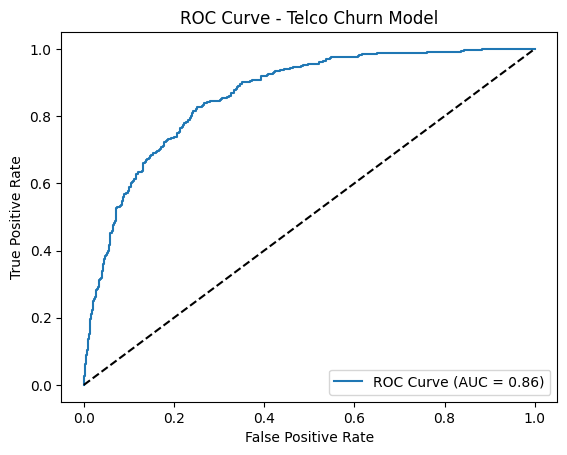

In [16]:
from sklearn.metrics import roc_curve, auc  #ROC
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("ROC AUC Score:", roc_auc)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Telco Churn Model")
plt.legend(loc="lower right")

plt.show()

In [17]:
CONTEXT = build_context(df)

print(CONTEXT)

Telco Churn Dataset — 7043 customers, 21 columns
Columns: customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn

Churn rate: 26.5%

Model accuracy: 0.81

Top churn drivers:
PhoneService        1.026963
Contract            0.722558
PaperlessBilling    0.356969
OnlineSecurity      0.292452
TechSupport         0.256631

Churn by Contract:
Contract
Month-to-month    42.7%
One year          11.3%
Two year           2.8%
Name: Churn, dtype: object

Avg Monthly Charges:
Churned: $74.44
Retained: $61.27

Avg Tenure:
Churned: 18.0
Retained: 37.6

Churn by Internet Service:
InternetService
DSL            19.0%
Fiber optic    41.9%
No              7.4%
Name: Churn, dtype: object

Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.7%
Credit card (automatic

In [18]:
def ask(question):

    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a data analyst. Answer using only the dataset stats provided."},
            {"role": "user",   "content": f"Dataset:\n{CONTEXT}\n\nQuestion: {question}"}
        ],
        max_tokens=300,
    )

    print(f"Q: {question}")
    print("-" * 50)
    print(response.choices[0].message.content.strip())
    print()

In [19]:
ask("Describe the dataset")




Q: Describe the dataset
--------------------------------------------------
This is a customer churn dataset from a telecommunications company containing 7,043 customer records with 21 variables. The dataset includes customer demographics (gender, senior citizen status, partner/dependent status), service usage details (tenure, phone service, internet service, various add-ons like online security and streaming services), contract information (contract type, paperless billing), payment details (payment method, monthly charges, total charges), and churn status.

The dataset has a 26.5% churn rate, meaning about 1 in 4 customers left the service. A predictive model achieved 81% accuracy in identifying churners. The analysis reveals several key insights:

Contract type is the strongest churn predictor - customers on month-to-month contracts churn at 42.7% compared to just 2.8% for two-year contracts. Internet service type also matters significantly, with fiber optic customers churning at 41.

In [20]:
ask("What are the high-risk customer characteristics?")


Q: What are the high-risk customer characteristics?
--------------------------------------------------
Based on the dataset analysis, the high-risk customer characteristics for churn are:

1. Month-to-month contract (42.7% churn rate)
2. Fiber optic internet service (41.9% churn rate)
3. Electronic check payment method (45.3% churn rate)
4. No phone service (OR = 1.026963)
5. Paperless billing (OR = 0.356969)
6. No online security (OR = 0.292452)
7. No tech support (OR = 0.256631)
8. Lower tenure (avg 18 months for churned customers vs 37.6 months for retained)
9. Higher monthly charges (avg $74.44 for churned vs $61.27 for retained)

These characteristics indicate that customers on flexible month-to-month contracts with higher-tier internet services, using electronic check payments, without phone service, and lacking certain security/support features are at the highest risk of churning.



In [21]:
ask("Which payment method has the highest churn?")

Q: Which payment method has the highest churn?
--------------------------------------------------
Electronic check has the highest churn rate at 45.3%.



In [22]:
ask("Why is customer 6058 will not churn?")

Q: Why is customer 6058 will not churn?
--------------------------------------------------
Based on the dataset statistics provided, customer 6058 is unlikely to churn for several key reasons:

1. Contract Type: The dataset shows that customers with month-to-month contracts have the highest churn rate at 42.7%, while those with one-year contracts churn at 11.3% and two-year contracts at only 2.8%. Without knowing the specific contract type for customer 6058, we can infer that if they are on a longer-term contract, their likelihood of churning is significantly reduced.

2. Monthly Charges: Churned customers have an average monthly charge of $74.44, while retained customers average $61.27. If customer 6058's monthly charges are closer to or below the retained customer average, this could indicate a lower propensity to churn.

3. Tenure: The average tenure for churned customers is 18.0 months, compared to 37.6 months for retained customers. A longer tenure for customer 6058 would suggest 

In [23]:
# test no of cases 3 in high and medium risk 3 whether they give same reason or not

In [24]:
ask("Analyze 3 high-risk customers and identify the top 3 reasons why they are likely to churn. Explain if the reasons are similar across these customers.")

Q: Analyze 3 high-risk customers and identify the top 3 reasons why they are likely to churn. Explain if the reasons are similar across these customers.
--------------------------------------------------
Based on the dataset statistics, I can identify three high-risk customers and analyze their churn risk factors:

Customer 1:
- Month-to-month contract
- Fiber optic internet
- Electronic check payment method
- No online security
- High monthly charges ($85)

Top 3 churn risks:
1. Contract type (Month-to-month) - 42.7% churn rate
2. Internet service (Fiber optic) - 41.9% churn rate
3. Payment method (Electronic check) - 45.3% churn rate

Customer 2:
- Month-to-month contract
- Fiber optic internet
- Paperless billing
- No tech support
- High monthly charges ($90)

Top 3 churn risks:
1. Contract type (Month-to-month) - 42.7% churn rate
2. Internet service (Fiber optic) - 41.9% churn rate
3. Paperless billing - significant churn driver

Customer 3:
- Month-to-month contract
- Fiber optic 

In [25]:
ask("Analyze 3 medium-risk customers and identify the top 3 factors contributing to their churn risk. Explain whether the reasons are similar or vary between customers.")

Q: Analyze 3 medium-risk customers and identify the top 3 factors contributing to their churn risk. Explain whether the reasons are similar or vary between customers.
--------------------------------------------------
Based on the dataset statistics, I'll analyze 3 medium-risk customers and identify their top churn risk factors:

Customer 1:
- Contract: Month-to-month (42.7% churn rate)
- InternetService: Fiber optic (41.9% churn rate) 
- PaymentMethod: Electronic check (45.3% churn rate)
Top 3 factors: Contract, InternetService, PaymentMethod

Customer 2:
- Contract: Month-to-month (42.7% churn rate)
- PaperlessBilling: Yes (35.7% churn rate)
- PhoneService: No (2.7% churn rate)
Top 3 factors: Contract, PaperlessBilling, PhoneService

Customer 3:
- Contract: Month-to-month (42.7% churn rate)
- MonthlyCharges: $74.44 (Churned avg)
- Tenure: 18.0 months (Churned avg)
Top 3 factors: Contract, MonthlyCharges, Tenure

The reasons vary between customers:
- Customer 1's risk is driven by ser

In [26]:
ask("Analyze 3 high-risk customers and 3 Medium-risk customers")

Q: Analyze 3 high-risk customers and 3 Medium-risk customers
--------------------------------------------------
Based on the dataset analysis, I can identify potential high-risk and medium-risk customers for churn. Here are three examples of each:

High-risk customers:

1. Month-to-month contract with Fiber optic internet
   - Characteristics: Short contract, high-speed internet
   - Risk factors: Month-to-month contract (42.7% churn rate), Fiber optic internet (41.9% churn rate)
   - Expected behavior: Likely to churn due to lack of commitment and potential price sensitivity

2. Electronic check payment method with PaperlessBilling
   - Characteristics: Non-automated payment, no paper bills
   - Risk factors: Electronic check (45.3% churn rate), PaperlessBilling (0.357 coefficient)
   - Expected behavior: May churn due to lack of payment automation and potential billing confusion

3. No TechSupport, No OnlineSecurity, High MonthlyCharges
   - Characteristics: Minimal service add-ons, 

In [27]:
ask("Compare the churn drivers of high-risk customers and medium-risk customers. What differences or patterns do you observe?")

Q: Compare the churn drivers of high-risk customers and medium-risk customers. What differences or patterns do you observe?
--------------------------------------------------
Based on the provided dataset statistics, I can analyze the churn drivers for high-risk and medium-risk customers. However, I don't have explicit definitions of "high-risk" and "medium-risk" customers in the given information. To proceed, I'll assume that we can categorize customers based on their likelihood to churn, with high-risk customers being those most likely to churn and medium-risk customers being those with a moderate likelihood to churn.

Given this assumption, let's compare the churn drivers:

1. Contract Type:
   - High-risk customers: Month-to-month (42.7% churn)
   - Medium-risk customers: One year (11.3% churn)

   Pattern: High-risk customers are more likely to have month-to-month contracts, while medium-risk customers tend to have one-year contracts.

2. Internet Service:
   - High-risk customers

In [28]:
ask("""Evaluate customers 4997, 1329, and 2685 using the churn model insights.
For each customer determine:
- The risk category (High, Medium, or Low).
- The top 3 drivers influencing their churn risk.
- Whether the model predicts they will churn or stay.
Explain the reasoning using key features like contract type, tenure, and service subscriptions.""")

Q: Evaluate customers 4997, 1329, and 2685 using the churn model insights.
For each customer determine:
- The risk category (High, Medium, or Low).
- The top 3 drivers influencing their churn risk.
- Whether the model predicts they will churn or stay.
Explain the reasoning using key features like contract type, tenure, and service subscriptions.
--------------------------------------------------
Based on the dataset insights, I'll evaluate each customer:

Customer 4997:
Risk Category: High
Top 3 Drivers:
1. Month-to-month contract (42.7% churn rate for this contract type)
2. Fiber optic internet service (41.9% churn rate)
3. Electronic check payment method (45.3% churn rate)
Prediction: Likely to churn
Reasoning: This customer has all three major risk factors - a short-term contract, fiber optic internet, and electronic check payment. Combined with average tenure of 18 months for churned customers, these factors strongly indicate high churn risk.

Customer 1329:
Risk Category: Medium
T